<a href="https://colab.research.google.com/github/Gussnogue/ifnmg-artificial-intelligence-MLPclassifier-neural-perceptron/blob/main/aula_pratica_complementar_1_3_mlpclassifier_GustavoSilvaNogueira_IFNMG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 1.3 — MLPClassifier (prática complementar)

**Disciplina:** Programação em Python para IA — IFNMG/Ceadi

Notebook **complementar** à videoaula: aqui você roda o `MLPClassifier` sobre uma amostra do dataset de **triagem de COVID** (e-SUS Notifica), avalia com **acurácia** e revisa a **matriz de confusão** e o **classification_report**.

**No Colab:** faça upload de `triagem-covid-amostra.csv` (arraste para a barra lateral clicando no símbolo de pasta). Rode as células na ordem (Shift+Enter).

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

## 1. Carregar os dados
Cada linha é um caso; as colunas são sintomas, estado, faixa etária, raça e estação (já em 0/1). A coluna `target` é o rótulo: 1 = COVID confirmado, 0 = descartado.

In [55]:
df = pd.read_csv("/content/content/triagem-covid-amostra-raw.csv")
df.head()

,estado,idade,racacor,estacao,sint_tosse,sint_febre,sint_dor_cabeca,sint_dor_garganta,sint_coriza,sint_dispneia,sint_anosmia_ageusia,cond_respiratoria,target
0,RJ,50,Nao informado,verao,0,0,0,0,0,0,0,0,1
1,SP,24,Parda,outono,0,1,0,1,1,0,0,0,0
2,SP,6,Branca,outono,1,1,0,0,1,0,0,0,0
3,SP,6,Branca,inverno,0,0,0,0,0,0,0,0,0
4,RJ,37,Outra,primavera,0,1,1,0,0,0,0,0,0


### Conhecer os dados
Antes de modelar, veja os **tipos** das colunas e um resumo (`describe`). Aqui todas as colunas já são numéricas (0/1).

In [51]:
print("tipos de coluna:")
print(df.dtypes.value_counts())
print()
df.describe()

tipos de coluna:
int64     10
object     3
Name: count, dtype: int64



,idade,sint_tosse,sint_febre,sint_dor_cabeca,sint_dor_garganta,sint_coriza,sint_dispneia,sint_anosmia_ageusia,cond_respiratoria,target
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,30.951000,0.540750,0.367250,0.420250,0.364000,0.451000,0.096750,0.071750,0.018250,0.474000
std,13.814424,0.498399,0.482116,0.493661,0.481209,0.497655,0.295654,0.258106,0.133871,0.499386
min,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,24.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,37.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,37.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,50.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 3. Dividir em treino e teste
`train_test_split` separa os dados: o modelo **aprende no treino** e é **avaliado no teste** (dados que ele nunca viu).
- `test_size=0.2`: 20% para teste.
- `stratify=y`: mantém a mesma proporção de classes nos dois conjuntos.
- `random_state=42`: torna a divisão reproduzível (sempre a mesma).

In [52]:
y = df["target"]
X = df.drop(columns=["target"])
print("nº de features:", X.shape[1])

nº de features: 12


## 3. Dividir em treino e teste

In [53]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("treino:", X_tr.shape[0], "| teste:", X_te.shape[0])

treino: 3200 | teste: 800


In [57]:
from sklearn.preprocessing import OneHotEncoder

# Identificar as colunas categóricas
categorical_cols = ['estado', 'racacor', 'estacao']

# Criar uma instância do OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Ajustar e transformar as colunas categóricas no conjunto de treino
X_tr_encoded = ohe.fit_transform(X_tr[categorical_cols])

# Transformar as colunas categóricas no conjunto de teste usando o encoder ajustado no treino
X_te_encoded = ohe.transform(X_te[categorical_cols])

# Criar DataFrames com as colunas codificadas
X_tr_encoded_df = pd.DataFrame(X_tr_encoded, columns=ohe.get_feature_names_out(categorical_cols), index=X_tr.index)
X_te_encoded_df = pd.DataFrame(X_te_encoded, columns=ohe.get_feature_names_out(categorical_cols), index=X_te.index)

# Remover as colunas categóricas originais e concatenar com as codificadas
X_tr = pd.concat([X_tr.drop(columns=categorical_cols), X_tr_encoded_df], axis=1)
X_te = pd.concat([X_te.drop(columns=categorical_cols), X_te_encoded_df], axis=1)

print("Shape de X_tr após One-Hot Encoding:", X_tr.shape)
print("Shape de X_te após One-Hot Encoding:", X_te.shape)

display(X_tr.head())

Shape de X_tr após One-Hot Encoding: (3200, 20)
Shape de X_te após One-Hot Encoding: (800, 20)


,idade,sint_tosse,sint_febre,sint_dor_cabeca,sint_dor_garganta,sint_coriza,sint_dispneia,sint_anosmia_ageusia,cond_respiratoria,estado_MG,estado_RJ,estado_SP,racacor_Branca,racacor_Nao informado,racacor_Outra,racacor_Parda,estacao_inverno,estacao_outono,estacao_primavera,estacao_verao
3686,24,0,1,1,1,0,0,0,0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
90,6,0,1,0,0,1,0,0,0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2855,6,1,1,0,0,1,0,0,0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3439,24,1,0,1,0,1,1,0,0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1248,37,0,1,0,0,1,0,0,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


Agora que as colunas categóricas foram transformadas em numéricas usando `OneHotEncoder`, o modelo `MLPClassifier` poderá processar os dados corretamente. Note que o número de features aumentou devido à criação de novas colunas para cada categoria única.

## 4. Criar e treinar o MLPClassifier
A mesma MLP do Módulo 1.2, agora pronta no scikit-learn: camadas ocultas 128 → 16, ativação ReLU.

In [58]:
clf = MLPClassifier(
    hidden_layer_sizes=(128, 16),
    activation="relu",
    max_iter=300,
    early_stopping=True,
    random_state=42,
)
clf.fit(X_tr, y_tr)

MLPClassifier(early_stopping=True, hidden_layer_sizes=(128, 16), max_iter=300,
              random_state=42)

## 5. Prever a classe
`predict` devolve a classe final (0 ou 1) para cada caso de teste.

In [59]:
y_pred = clf.predict(X_te)
print("5 primeiras previsões:", y_pred[:5])

5 primeiras previsões: [0 0 1 0 1]


## 6. Avaliar com acurácia
Acurácia = proporção de previsões corretas. É a métrica mais simples de ler.

In [60]:
acc = accuracy_score(y_te, y_pred)
print("Acurácia:", round(acc, 3))

Acurácia: 0.626


## 7. Revisão: matriz de confusão e classification_report
Você já viu essas métricas em Inteligência Artificial. A **matriz de confusão** mostra acertos e erros por classe; o **classification_report** traz precision, recall e F1 de cada classe.

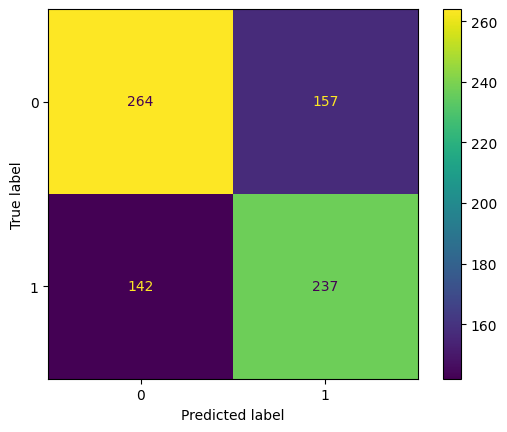

              precision    recall  f1-score   support

           0       0.65      0.63      0.64       421
           1       0.60      0.63      0.61       379

    accuracy                           0.63       800
   macro avg       0.63      0.63      0.63       800
weighted avg       0.63      0.63      0.63       800



In [61]:
cm = confusion_matrix(y_te, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=clf.classes_)
disp.plot()
plt.show()
print(classification_report(y_te, y_pred, digits=2))

## 8. Para pensar
A acurácia ficou em torno de 0,6. Olhando a matriz de confusão, o modelo erra mais em qual classe? Por que só a acurácia pode não contar a história toda?

R: Sugestão, implementar o método k-folds, para obtermos os devios padrões que podem elevar a eficiência do resultado. Tive uma descoberta com colunas float, utilizando o onehotencoder para auxiliar no processo para revisão.